In [136]:
import numpy as np

In [1]:
!pip install pandas openpyxl

In [2]:
%pip install scikit-learn

In [3]:
import pandas as pd

In [5]:
#Reading the dataset
df = pd.read_excel("./Online Retail.xlsx")

**Exploratory Data Analysis**

In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
df.shape

(541909, 8)

In [8]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [9]:
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [11]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [12]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [13]:
df.isnull()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
541904,False,False,False,False,False,False,False,False
541905,False,False,False,False,False,False,False,False
541906,False,False,False,False,False,False,False,False
541907,False,False,False,False,False,False,False,False


In [14]:
df[df["CustomerID"].isnull()]["Quantity"].describe()

,Quantity
count,135080.000000
mean,1.995573
std,66.696153
min,-9600.000000
25%,1.000000
50%,1.000000
75%,3.000000
max,5568.000000


In [15]:
df[df["Quantity"] < 0].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [16]:
df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(9288)

In [17]:
(df["InvoiceNo"].astype(str).str.startswith("C").mean()) * 100

np.float64(1.7139409015166756)

In [18]:
df[df["Quantity"] == -80995]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom


In [19]:
df["InvoiceNo"].astype(str).str[0].value_counts()

,count
InvoiceNo,
5,532618
C,9288
A,3


In [20]:
df[~df["InvoiceNo"].astype(str).str.isnumeric()]["InvoiceNo"].unique()[:50]

array(['C536379', 'C536383', 'C536391', 'C536506', 'C536543', 'C536548',
       'C536606', 'C536622', 'C536625', 'C536642', 'C536734', 'C536737',
       'C536757', 'C536758', 'C536760', 'C536807', 'C536812', 'C536814',
       'C536815', 'C536816', 'C536817', 'C536818', 'C536820', 'C536822',
       'C536825', 'C536826', 'C536827', 'C536828', 'C536829', 'C536850',
       'C536853', 'C536854', 'C536855', 'C536978', 'C536979', 'C537024',
       'C537039', 'C537043', 'C537132', 'C537143', 'C537157', 'C537164',
       'C537203', 'C537232', 'C537234', 'C537251', 'C537314', 'C537320',
       'C537333', 'C537373'], dtype=object)

In [21]:
df[df["InvoiceNo"].astype(str).str.startswith("C")]["Quantity"].describe()

,Quantity
count,9288.000000
mean,-29.885228
std,1145.786965
min,-80995.000000
25%,-6.000000
50%,-2.000000
75%,-1.000000
max,-1.000000


In [22]:
df[
    (df["Quantity"] < 0) &
    (~df["InvoiceNo"].astype(str).str.startswith("C"))
]["InvoiceNo"].head(20)

,InvoiceNo
2406,536589
4347,536764
7188,536996
7189,536997
7190,536998
7192,537000
7193,537001
7195,537003
7196,537004
7197,537005


In [23]:
df[df["InvoiceNo"] == "536589"]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [24]:
df[df["InvoiceNo"] == "536589"][[
    "InvoiceNo",
    "StockCode",
    "Description",
    "Quantity",
    "InvoiceDate",
    "UnitPrice",
    "CustomerID"
]]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID


In [25]:
(df["Quantity"] < 0).sum()

np.int64(10624)

In [26]:
(df["InvoiceNo"].astype(str).str.startswith("C")).sum()

np.int64(9288)

In [27]:
df[df["InvoiceNo"].astype(str).str.startswith("A")].shape

(3, 8)

In [28]:
df[df["InvoiceNo"].astype(str).str.startswith("A")].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [29]:
df[df["InvoiceNo"].astype(str).str.startswith("A")]["Quantity"].describe()

,Quantity
count,3.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [30]:
df[
    (df["Quantity"] < 0) &
    (~df["InvoiceNo"].astype(str).str.startswith("C")) &
    (~df["InvoiceNo"].astype(str).str.startswith("A"))
].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7192,537000,21414,NaN,-22,2010-12-03 15:32:00,0.0,NaN,United Kingdom
7193,537001,21653,NaN,-6,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7195,537003,85126,NaN,-2,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7196,537004,21814,NaN,-30,2010-12-03 15:34:00,0.0,NaN,United Kingdom
7197,537005,21692,NaN,-70,2010-12-03 15:35:00,0.0,NaN,United Kingdom


In [32]:
df[
    (df["Quantity"] < 0) &
    (~df["InvoiceNo"].astype(str).str.startswith("C")) &
    (~df["InvoiceNo"].astype(str).str.startswith("A"))
].shape

(1336, 8)

In [34]:
df[
    (df["Quantity"] < 0) &
    (~df["InvoiceNo"].astype(str).str.startswith("C")) &
    (~df["InvoiceNo"].astype(str).str.startswith("A"))
]["UnitPrice"].value_counts()

,count
UnitPrice,
0.0,1336


In [35]:
df["CustomerID"].nunique()

4372

In [36]:
df["CustomerID"].isnull().sum()

np.int64(135080)

**Data Cleaning**

In [37]:
#removed transactions where CustomerID
df_clean = df.dropna(subset=["CustomerID"])

In [38]:
df_clean["CustomerID"].nunique()

4372

In [39]:
df_clean.shape

(406829, 8)

In [40]:
#Since all the C-prefixed transactions had negative quantities, indicating cancellation/return-type transactions. We removed these aswell
df_clean = df_clean[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C")
]

In [41]:
df_clean.shape

(397924, 8)

In [42]:
df_clean["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(0)

In [43]:
# A-Prefixed were accounting adjustments rather than customer purchases and they had no CustomerID so they were already
# removed when we removed missing CustomerIDs

df_clean[df_clean["InvoiceNo"].astype(str).str.startswith("A")]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [44]:
df_clean[df_clean["Quantity"] < 0].shape

(0, 8)

In [46]:
#Saved the cleaned dataset in a CSV
df_clean.to_csv("./clean_transactions.csv", index=False)

In [ ]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [47]:
df_clean.shape

(397924, 8)

In [48]:
#checking the transaction dates for cleaned dataset
df_clean["InvoiceDate"].min()

Timestamp('2010-12-01 08:26:00')

In [49]:
df_clean["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

In [50]:
#cutoff date - Since we need 30 days of future data to determine whether someone purchased again.
#We have to move 30 days backward

cutoff_date = df_clean["InvoiceDate"].max() - pd.Timedelta(days=30)

cutoff_date

Timestamp('2011-11-09 12:50:00')

In [52]:
#separating the clean data into the feature period and the target period.
feature_data = df_clean[df_clean["InvoiceDate"] <= cutoff_date]

In [53]:
target_data = df_clean[df_clean["InvoiceDate"] > cutoff_date]

In [54]:
feature_data.shape

(332343, 8)

In [56]:
target_data.shape

(65581, 8)

In [58]:
feature_data["InvoiceDate"].min(), feature_data["InvoiceDate"].max()

(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-11-09 12:49:00'))

In [59]:
target_data["InvoiceDate"].min(), target_data["InvoiceDate"].max()

(Timestamp('2011-11-09 13:12:00'), Timestamp('2011-12-09 12:50:00'))

**Feature Engineering**

Since the dataset was transactional, but our model needs customer-level information

In [62]:
#Feature - 1: Recency calculation
last_purchase = feature_data.groupby("CustomerID")["InvoiceDate"].max()

In [63]:
recency = (cutoff_date - last_purchase).dt.days

In [64]:
recency.head()

,InvoiceDate
CustomerID,
12346.0,295
12347.0,9
12348.0,44
12350.0,279
12352.0,5


In [65]:
#Feature 2: Frequency
frequency = feature_data.groupby("CustomerID")["InvoiceNo"].nunique()

In [66]:
frequency.head()

,InvoiceNo
CustomerID,
12346.0,1
12347.0,6
12348.0,4
12350.0,1
12352.0,8


In [67]:
#Feature 3: Monetary
feature_data["TotalAmount"] = feature_data["Quantity"] * feature_data["UnitPrice"]

/tmp/ipykernel_2446/276933377.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feature_data["TotalAmount"] = feature_data["Quantity"] * feature_data["UnitPrice"]


In [68]:
feature_data[["Quantity", "UnitPrice", "TotalAmount"]].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [69]:
#Calculate Monetary per customer
monetary = feature_data.groupby("CustomerID")["TotalAmount"].sum()

In [70]:
monetary.head()

,TotalAmount
CustomerID,
12346.0,77183.60
12347.0,4085.18
12348.0,1797.24
12350.0,334.40
12352.0,2506.04


In [71]:
rfm = pd.concat([recency, frequency, monetary], axis=1)
rfm.head()

,InvoiceDate,InvoiceNo,TotalAmount
CustomerID,,,
12346.0,295,1,77183.60
12347.0,9,6,4085.18
12348.0,44,4,1797.24
12350.0,279,1,334.40
12352.0,5,8,2506.04


In [72]:
rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,295,1,77183.60
12347.0,9,6,4085.18
12348.0,44,4,1797.24
12350.0,279,1,334.40
12352.0,5,8,2506.04


In [73]:
#Feature 4:Total Quantity
total_quantity = feature_data.groupby("CustomerID")["Quantity"].sum()
total_quantity.head()

,Quantity
CustomerID,
12346.0,74215
12347.0,2266
12348.0,2341
12350.0,197
12352.0,536


In [74]:
#Feature 5: Unique Products
unique_products = feature_data.groupby("CustomerID")["StockCode"].nunique()
unique_products.head()

,StockCode
CustomerID,
12346.0,1
12347.0,100
12348.0,22
12350.0,17
12352.0,59


In [75]:
rfm["UniqueProducts"] = unique_products
rfm.head()

,Recency,Frequency,Monetary,UniqueProducts
CustomerID,,,,
12346.0,295,1,77183.60,1
12347.0,9,6,4085.18,100
12348.0,44,4,1797.24,22
12350.0,279,1,334.40,17
12352.0,5,8,2506.04,59


In [76]:
#Feature 6:Average Order Value
rfm["AverageOrderValue"] = rfm["Monetary"] / rfm["Frequency"]
rfm.head()

,Recency,Frequency,Monetary,UniqueProducts,AverageOrderValue
CustomerID,,,,,
12346.0,295,1,77183.60,1,77183.600000
12347.0,9,6,4085.18,100,680.863333
12348.0,44,4,1797.24,22,449.310000
12350.0,279,1,334.40,17,334.400000
12352.0,5,8,2506.04,59,313.255000


In [77]:
#Feature 7: Purchase Days
feature_data["PurchaseDate"] = feature_data["InvoiceDate"].dt.date

/tmp/ipykernel_2446/1098792232.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feature_data["PurchaseDate"] = feature_data["InvoiceDate"].dt.date


In [78]:
unique_purchase_days = feature_data.groupby("CustomerID")["PurchaseDate"].nunique()
unique_purchase_days.head()

,PurchaseDate
CustomerID,
12346.0,1
12347.0,6
12348.0,4
12350.0,1
12352.0,7


In [79]:
rfm["UniquePurchaseDays"] = unique_purchase_days
rfm.head()

,Recency,Frequency,Monetary,UniqueProducts,AverageOrderValue,UniquePurchaseDays
CustomerID,,,,,,
12346.0,295,1,77183.60,1,77183.600000,1
12347.0,9,6,4085.18,100,680.863333,6
12348.0,44,4,1797.24,22,449.310000,4
12350.0,279,1,334.40,17,334.400000,1
12352.0,5,8,2506.04,59,313.255000,7


In [80]:
#Feature 8: Customer Lifespan
first_purchase = feature_data.groupby("CustomerID")["InvoiceDate"].min()

In [81]:
customer_lifespan = (last_purchase - first_purchase).dt.days

In [82]:
customer_lifespan.head()

,InvoiceDate
CustomerID,
12346.0,0
12347.0,327
12348.0,282
12350.0,0
12352.0,260


In [83]:
#Calculating target data
repeat_customers = target_data["CustomerID"].unique()

In [84]:
len(repeat_customers)

1649

In [85]:
#Creating the target (label) in our table
rfm["Target"] = rfm.index.isin(repeat_customers).astype(int)
rfm.head()

,Recency,Frequency,Monetary,UniqueProducts,AverageOrderValue,UniquePurchaseDays,Target
CustomerID,,,,,,,
12346.0,295,1,77183.60,1,77183.600000,1,0
12347.0,9,6,4085.18,100,680.863333,6,1
12348.0,44,4,1797.24,22,449.310000,4,0
12350.0,279,1,334.40,17,334.400000,1,0
12352.0,5,8,2506.04,59,313.255000,7,0


In [86]:
rfm["Target"].value_counts()

,count
Target,
0,2690
1,1380


In [ ]:
#Checking the complete dataset and its data types/missing values before adding more features
rfm.shape

(4070, 7)

In [87]:
rfm.isnull().sum()

,0
Recency,0
Frequency,0
Monetary,0
UniqueProducts,0
AverageOrderValue,0
UniquePurchaseDays,0
Target,0


In [88]:
rfm.dtypes

,0
Recency,int64
Frequency,int64
Monetary,float64
UniqueProducts,int64
AverageOrderValue,float64
UniquePurchaseDays,int64
Target,int64


In [89]:
rfm["CustomerLifespan"] = customer_lifespan

In [90]:
rfm.shape

(4070, 8)

In [91]:
rfm.isnull().sum()

,0
Recency,0
Frequency,0
Monetary,0
UniqueProducts,0
AverageOrderValue,0
UniquePurchaseDays,0
Target,0
CustomerLifespan,0


In [92]:
#Feature 9 - OrdersLast30Days
last_30_days_start = cutoff_date - pd.Timedelta(days=30)
last_30_days_start

Timestamp('2011-10-10 12:50:00')

In [93]:
orders_last_30_days = (
    feature_data[
        feature_data["InvoiceDate"] > last_30_days_start
    ]
    .groupby("CustomerID")["InvoiceNo"]
    .nunique()
)

In [94]:
orders_last_30_days.head()

,InvoiceNo
CustomerID,
12347.0,1
12352.0,1
12357.0,1
12359.0,1
12360.0,1


In [95]:
rfm["OrdersLast30Days"] = orders_last_30_days

In [96]:
rfm["OrdersLast30Days"] = rfm["OrdersLast30Days"].fillna(0).astype(int)

In [97]:
rfm.shape

(4070, 9)

In [98]:
rfm.head()
#Validating our customer-level dataset

,Recency,Frequency,Monetary,UniqueProducts,AverageOrderValue,UniquePurchaseDays,Target,CustomerLifespan,OrdersLast30Days
CustomerID,,,,,,,,,
12346.0,295,1,77183.60,1,77183.600000,1,0,0,0
12347.0,9,6,4085.18,100,680.863333,6,1,327,1
12348.0,44,4,1797.24,22,449.310000,4,0,282,0
12350.0,279,1,334.40,17,334.400000,1,0,0,0
12352.0,5,8,2506.04,59,313.255000,7,0,260,1


In [99]:
rfm.describe()

,Recency,Frequency,Monetary,UniqueProducts,AverageOrderValue,UniquePurchaseDays,Target,CustomerLifespan,OrdersLast30Days
count,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000
mean,92.340786,3.881327,1857.572458,56.896314,408.295791,3.512039,0.339066,113.164128,0.510319
std,95.350702,6.782034,8024.826222,78.521281,1306.637500,5.316683,0.473451,119.452734,1.014162
min,0.000000,1.000000,2.900000,1.000000,2.900000,1.000000,0.000000,0.000000,0.000000
25%,19.000000,1.000000,298.087500,15.000000,178.430000,1.000000,0.000000,0.000000,0.000000
50%,49.000000,2.000000,640.550000,33.000000,298.837500,2.000000,0.000000,74.000000,0.000000
75%,149.000000,4.000000,1543.617500,71.000000,435.724250,4.000000,1.000000,223.000000,1.000000
max,343.000000,164.000000,247885.680000,1633.000000,77183.600000,109.000000,1.000000,343.000000,26.000000


**Data Validation**

In [100]:
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,4070.0,92.340786,95.350702,0.0,19.0000,49.0000,149.00000,343.00
Frequency,4070.0,3.881327,6.782034,1.0,1.0000,2.0000,4.00000,164.00
Monetary,4070.0,1857.572458,8024.826222,2.9,298.0875,640.5500,1543.61750,247885.68
UniqueProducts,4070.0,56.896314,78.521281,1.0,15.0000,33.0000,71.00000,1633.00
AverageOrderValue,4070.0,408.295791,1306.637500,2.9,178.4300,298.8375,435.72425,77183.60
UniquePurchaseDays,4070.0,3.512039,5.316683,1.0,1.0000,2.0000,4.00000,109.00
Target,4070.0,0.339066,0.473451,0.0,0.0000,0.0000,1.00000,1.00
CustomerLifespan,4070.0,113.164128,119.452734,0.0,0.0000,74.0000,223.00000,343.00
OrdersLast30Days,4070.0,0.510319,1.014162,0.0,0.0000,0.0000,1.00000,26.00


**Separating Features(X) and Target (Y)**

In [101]:
X = rfm.drop("Target", axis=1)

In [102]:
Y = rfm["Target"]

In [103]:
X.shape

(4070, 8)

In [104]:
Y.shape

(4070,)

**Splitting training and testing data**

In [105]:
import sklearn

In [106]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42,
    stratify=Y
)

In [107]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((3256, 8), (814, 8), (3256,), (814,))

In [108]:
#feature scaling
from sklearn.preprocessing import StandardScaler

In [109]:
scaler = StandardScaler()

In [110]:
X_train_scaled = scaler.fit_transform(X_train)

In [111]:
X_test_scaled = scaler.transform(X_test)

In [112]:
X_train_scaled.shape, X_test_scaled.shape

((3256, 8), (814, 8))

**Model Training**

In [113]:
#We are starting of with Logistic Regression since it is binary classification problem.
from sklearn.linear_model import LogisticRegression

In [114]:
model = LogisticRegression(random_state=42)

In [115]:
model.fit(X_train_scaled, Y_train)

LogisticRegression(random_state=42)

In [116]:
Y_pred = model.predict(X_test_scaled)

In [117]:
Y_pred[:20]

array([1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0])

In [118]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)

accuracy, precision, recall, f1

(0.7248157248157249, 0.6625, 0.38405797101449274, 0.48623853211009177)

In [119]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, Y_pred)

cm

array([[484,  54],
       [170, 106]])

In [120]:
model.coef_

array([[-0.24854339, -0.13343898, -0.01560069,  0.38391063, -0.17450945,
         1.18477976,  0.02127258,  0.08403557]])

In [121]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients

,Feature,Coefficient
0,Recency,-0.248543
1,Frequency,-0.133439
2,Monetary,-0.015601
3,UniqueProducts,0.383911
4,AverageOrderValue,-0.174509
5,UniquePurchaseDays,1.184780
6,CustomerLifespan,0.021273
7,OrdersLast30Days,0.084036


## Model Training with RandomForestClassifier

In [122]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train a RandomForestClassifier model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, Y_train)

RandomForestClassifier(random_state=42)

In [123]:
# Make predictions on the scaled test set
Y_pred_rf = rf_model.predict(X_test_scaled)

## Model Evaluation for RandomForestClassifier

In [124]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Calculate evaluation metrics for the Random Forest model
accuracy_rf = accuracy_score(Y_test, Y_pred_rf)
precision_rf = precision_score(Y_test, Y_pred_rf)
recall_rf = recall_score(Y_test, Y_pred_rf)
f1_rf = f1_score(Y_test, Y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Precision: {precision_rf:.4f}")
print(f"Random Forest Recall: {recall_rf:.4f}")
print(f"Random Forest F1-score: {f1_rf:.4f}")

# Display the confusion matrix
cm_rf = confusion_matrix(Y_test, Y_pred_rf)
print("\nRandom Forest Confusion Matrix:")
print(cm_rf)

Random Forest Accuracy: 0.7015
Random Forest Precision: 0.5775
Random Forest Recall: 0.4457
Random Forest F1-score: 0.5031

Random Forest Confusion Matrix:
[[448  90]
 [153 123]]


## Model Training with LightGBM Classifier

In [125]:
import lightgbm as lgb

# Initialize and train a LightGBM Classifier model
lgbm_model = lgb.LGBMClassifier(random_state=42)
lgbm_model.fit(X_train_scaled, Y_train)

[LightGBM] [Info] Number of positive: 1104, number of negative: 2152
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000490 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1339
[LightGBM] [Info] Number of data points in the train set: 3256, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.339066 -> initscore=-0.667458
[LightGBM] [Info] Start training from score -0.667458


LGBMClassifier(random_state=42)

In [126]:
# Make predictions on the scaled test set
Y_pred_lgbm = lgbm_model.predict(X_test_scaled)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Model Evaluation for LightGBM Classifier

In [127]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Calculate evaluation metrics for the LightGBM model
accuracy_lgbm = accuracy_score(Y_test, Y_pred_lgbm)
precision_lgbm = precision_score(Y_test, Y_pred_lgbm)
recall_lgbm = recall_score(Y_test, Y_pred_lgbm)
f1_lgbm = f1_score(Y_test, Y_pred_lgbm)

print(f"LightGBM Accuracy: {accuracy_lgbm:.4f}")
print(f"LightGBM Precision: {precision_lgbm:.4f}")
print(f"LightGBM Recall: {recall_lgbm:.4f}")
print(f"LightGBM F1-score: {f1_lgbm:.4f}")

# Display the confusion matrix
cm_lgbm = confusion_matrix(Y_test, Y_pred_lgbm)
print("\nLightGBM Confusion Matrix:")
print(cm_lgbm)

LightGBM Accuracy: 0.7273
LightGBM Precision: 0.6421
LightGBM Recall: 0.4420
LightGBM F1-score: 0.5236

LightGBM Confusion Matrix:
[[470  68]
 [154 122]]


## Understanding Overfitting, Underfitting, and Variance

When training machine learning models, it's crucial to understand three core concepts:

*   **Underfitting (High Bias):** Occurs when a model is too simple to capture the underlying patterns in the data. It performs poorly on both the training data and unseen test data. On a learning curve, both training and cross-validation scores will be low and converge at a low value.

*   **Overfitting (High Variance):** Occurs when a model is too complex and learns the noise and specific details of the training data rather than the general patterns. It performs very well on the training data but poorly on unseen test data. On a learning curve, the training score will be very high, while the cross-validation score will be significantly lower, and there will be a large gap between them.

*   **Variance:** Refers to the model's sensitivity to fluctuations in the training data. A model with high variance will change significantly with different training sets, leading to inconsistent performance. Learning curves can show variance when the training score is much higher than the cross-validation score.

**Learning Curves** are a powerful tool to diagnose these issues by plotting the model's performance on the training set and the cross-validation set as a function of the number of training examples or the complexity of the model. They help us identify if adding more data or adjusting model complexity would improve performance.

In [132]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.model_selection import StratifiedKFold
import numpy as np # Added this import

# Function to plot learning curves
def plot_learning_curve(estimator, title, X, y, axes=None, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):

    if axes is None:
        _, axes = plt.subplots(1, 1, figsize=(10, 5))

    axes.set_title(title)
    if ylim is not None:
        axes.set_ylim(*ylim)
    axes.set_xlabel("Training examples")
    axes.set_ylabel("Score")

    train_sizes, train_scores, test_scores, fit_times, _ = \
        learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs,
                       train_sizes=train_sizes, return_times=True)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    fit_times_mean = np.mean(fit_times, axis=1)
    fit_times_std = np.std(fit_times, axis=1)

    # Plot learning curve
    axes.grid()
    axes.fill_between(train_sizes, train_scores_mean - train_scores_std,
                         train_scores_mean + train_scores_std, alpha=0.1,
                         color="r")
    axes.fill_between(train_sizes, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1,
                         color="g")
    axes.plot(train_sizes, train_scores_mean, 'o-', color="r",
                 label="Training score")
    axes.plot(train_sizes, test_scores_mean, 'o-', color="g",
                 label="Cross-validation score")
    axes.legend(loc="best")

    return plt

### Learning Curves for Logistic Regression

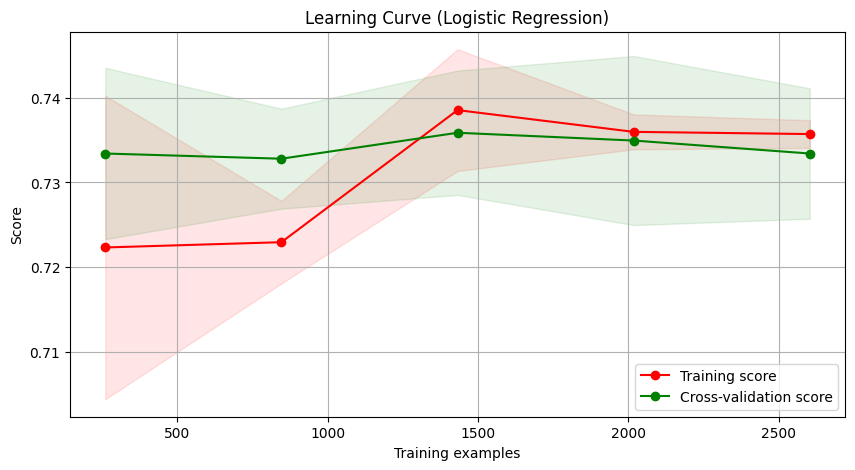

In [133]:
from sklearn.linear_model import LogisticRegression
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression
estimator_lr = LogisticRegression(random_state=42, solver='liblinear') # Use 'liblinear' for smaller datasets or L1/L2 regularization

fig_lr = plot_learning_curve(estimator_lr, "Learning Curve (Logistic Regression)",
                             X_train_scaled, Y_train, cv=cv, n_jobs=-1)
plt.show()

### Learning Curves for Random Forest Classifier

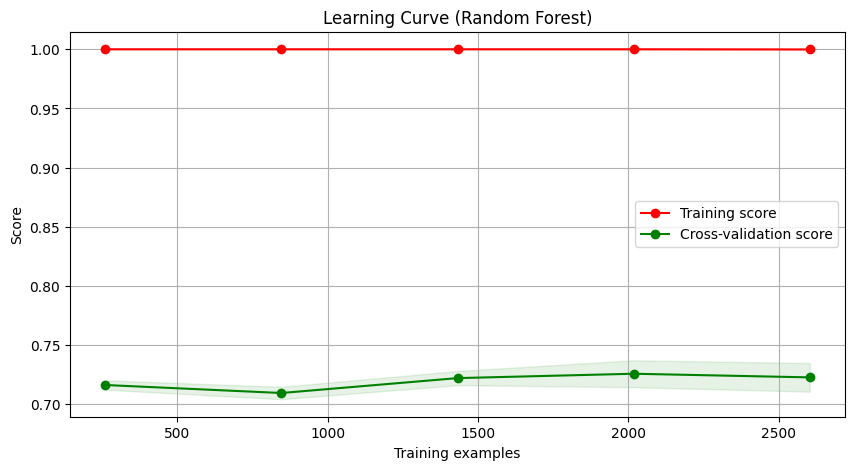

In [134]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest Classifier
estimator_rf = RandomForestClassifier(random_state=42, n_estimators=100) # Increased n_estimators for better performance

fig_rf = plot_learning_curve(estimator_rf, "Learning Curve (Random Forest)",
                             X_train_scaled, Y_train, cv=cv, n_jobs=-1)
plt.show()

### Learning Curves for LightGBM Classifier

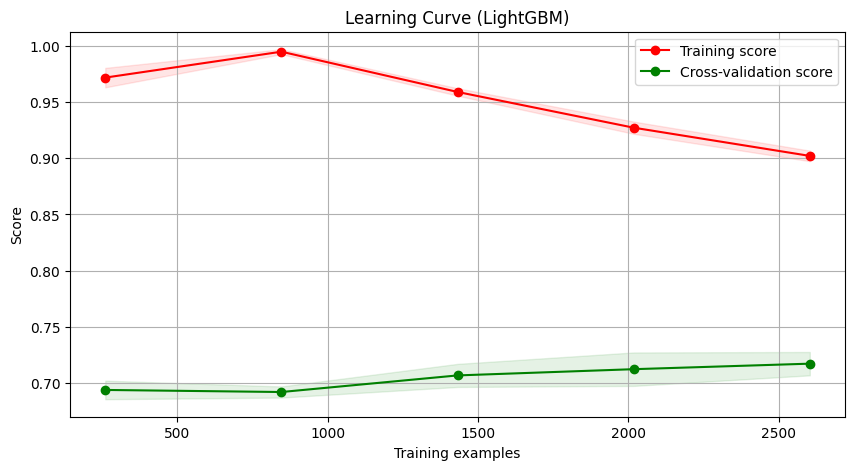

In [135]:
import lightgbm as lgb

# LightGBM Classifier
estimator_lgbm = lgb.LGBMClassifier(random_state=42)

fig_lgbm = plot_learning_curve(estimator_lgbm, "Learning Curve (LightGBM)",
                               X_train_scaled, Y_train, cv=cv, n_jobs=-1)
plt.show()

## Interpreting the Learning Curves

**Logistic Regression:**
*   If both training and cross-validation scores are low and converge, it indicates **underfitting** (high bias). The model might be too simple to capture the complexity of the data.
*   If there's a small gap between training and cross-validation scores, it suggests **low variance**, meaning the model generalizes well but might be constrained by its simplicity.

**Random Forest Classifier:**
*   Often, Random Forests show a very high training score and a lower, but improving, cross-validation score. A significant gap between the two, even with increasing training data, can indicate **overfitting** (high variance), especially if `n_estimators` is too high or `max_depth` is unrestricted.
*   The cross-validation score should ideally converge to a high value. If it plateaus at a relatively low value, the model might still be somewhat underfitting the true patterns in the unseen data.

**LightGBM Classifier:**
*   Similar to Random Forest, LightGBM models can also show signs of **overfitting** if the training score is much higher than the cross-validation score. However, boosting algorithms often achieve a better bias-variance trade-off by iteratively correcting errors.
*   If the cross-validation score continues to improve with more data and converges close to the training score (without too large a gap), it indicates a good balance and effective generalization. A large gap still points to variance.

**General Observations for all models:**
*   **High Variance (Overfitting):** A large gap between the training score and the cross-validation score, with the training score being much higher.
*   **High Bias (Underfitting):** Both the training score and the cross-validation score are low, even with more training data.
*   **Good Fit:** Training and cross-validation scores are both high and converge close to each other. The model is learning well and generalizing effectively.

By examining these plots, we can get insights into the bias-variance trade-off of each model and consider further tuning (e.g., regularization for Logistic Regression, `max_depth` or `min_samples_leaf` for Random Forest, `num_leaves` or `n_estimators` for LightGBM) or feature engineering to improve performance.

## Feature Importance Analysis

Let's examine the most influential features for each trained model based on their coefficients (for Logistic Regression) and feature importances (for tree-based models).

### Logistic Regression Feature Coefficients

For Logistic Regression, the coefficients indicate the strength and direction of the relationship between each feature and the log-odds of the target variable. A larger absolute value of the coefficient implies a stronger influence.

In [137]:
import pandas as pd

# Coefficients for Logistic Regression
coefficients_lr = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print("Logistic Regression Feature Coefficients:")
display(coefficients_lr)

Logistic Regression Feature Coefficients:


,Feature,Coefficient
5,UniquePurchaseDays,1.184780
3,UniqueProducts,0.383911
7,OrdersLast30Days,0.084036
6,CustomerLifespan,0.021273
2,Monetary,-0.015601
1,Frequency,-0.133439
4,AverageOrderValue,-0.174509
0,Recency,-0.248543


### Random Forest Feature Importances

For tree-based models like Random Forest, feature importance is typically calculated as the (normalized) total reduction of the criterion (e.g., Gini impurity) brought by that feature. A higher value indicates a more important feature.

In [138]:
# Feature Importances for Random Forest
feature_importances_rf = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Random Forest Feature Importances:")
display(feature_importances_rf)

Random Forest Feature Importances:


,Feature,Importance
2,Monetary,0.188606
0,Recency,0.165764
4,AverageOrderValue,0.164150
3,UniqueProducts,0.163626
6,CustomerLifespan,0.127719
1,Frequency,0.086959
5,UniquePurchaseDays,0.078577
7,OrdersLast30Days,0.024600


### LightGBM Feature Importances

LightGBM also provides feature importances, usually based on the number of times a feature is used in a split (split gain) or the total gain associated with that feature. Higher values denote more impactful features.

In [139]:
# Feature Importances for LightGBM
feature_importances_lgbm = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lgbm_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("LightGBM Feature Importances:")
display(feature_importances_lgbm)

LightGBM Feature Importances:


,Feature,Importance
0,Recency,631
3,UniqueProducts,594
4,AverageOrderValue,525
2,Monetary,508
6,CustomerLifespan,471
5,UniquePurchaseDays,123
1,Frequency,90
7,OrdersLast30Days,58
